# Transfer Learning for Phosphene-Based Object Recognition in Cortical Visual Prostheses

**Author:** Research Notebook
**Project:** Deep Learning for Visual Prostheses
**Objective:** Compare transfer learning vs. from-scratch training on phosphene-simulated images

---

## Abstract

This notebook implements a complete research pipeline for studying how transfer learning from natural images affects performance on phosphene-simulated visual data. We simulate phosphenes (artificial visual perceptions produced by cortical visual prostheses) and compare the performance of pretrained models versus randomly initialized models on this degraded visual input.

---

## 1. Setup & Imports

In [1]:
# Import all necessary libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Torchvision imports
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Print versions
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


## 2. Phosphene Simulation Function

### 2.1 Understanding Phosphenes

Phosphenes are artificial visual perceptions that occur when visual cortex is electrically stimulated. They appear as dots or small patches of light. Key characteristics:
- **Resolution:** Limited by electrode array (typically 60-1000 electrodes)
- **Shape:** Typically round/elliptical
- **Brightness:** Varies with stimulation intensity
- **Noise:** Biological noise from neural tissue

In [2]:
class PhospheneSimulation:
    """
    Simulates phosphene vision for cortical visual prostheses.

    This transform simulates how a bionic eye "sees" by applying:
    1. Gaussian blur (simulates spread of electrical current)
    2. Downsampling (simulates limited electrode resolution)
    3. Thresholding (creates dot-like patterns)
    4. Random noise (biological/electrical noise)
    """

    def __init__(self,
                 phosphene_size=64,      # Resolution of phosphene grid
                 gaussian_sigma=2.0,     # Blur amount (current spread)
                 threshold_ratio=0.3,    # Threshold for binarization
                 noise_prob=0.1,         # Probability of noise
                 noise_intensity=0.15):  # Noise strength
        self.phosphene_size = phosphene_size
        self.gaussian_sigma = gaussian_sigma
        self.threshold_ratio = threshold_ratio
        self.noise_prob = noise_prob
        self.noise_intensity = noise_intensity

    def __call__(self, img):
        """
        Apply phosphene simulation to a PIL image.

        Args:
            img: PIL Image (RGB or L)

        Returns:
            PIL Image with phosphene simulation applied
        """
        # Convert to numpy array
        img_array = np.array(img)

        # Ensure grayscale for processing if needed
        if len(img_array.shape) == 3:
            # Convert to grayscale using luminance
            img_array = np.mean(img_array, axis=2).astype(np.uint8)

        # Step 1: Apply Gaussian blur (simulates spread of electrical current)
        # Using simple kernel-based blur as approximation
        from scipy.ndimage import gaussian_filter
        blurred = gaussian_filter(img_array.astype(float), sigma=self.gaussian_sigma)

        # Step 2: Downsample to phosphene resolution
        from PIL import Image as PILImage
        small = PILImage.fromarray(blurred.astype(np.uint8))
        small = small.resize((self.phosphene_size, self.phosphene_size), PILImage.BILINEAR)
        small_array = np.array(small)

        # Step 3: Thresholding to create dot-like phosphene patterns
        # Normalize to 0-1 range
        normalized = small_array.astype(float) / 255.0
        threshold = np.percentile(normalized, 100 * (1 - self.threshold_ratio))
        phosphene_pattern = (normalized > threshold).astype(float)

        # Step 4: Add random noise (biological/electrical noise)
        if random.random() < self.noise_prob:
            noise = np.random.randn(*phosphene_pattern.shape) * self.noise_intensity
            phosphene_pattern = np.clip(phosphene_pattern + noise, 0, 1)

        # Convert back to 0-255 grayscale
        result = (phosphene_pattern * 255).astype(np.uint8)

        return PILImage.fromarray(result, mode='L')


# Alternative simpler version without scipy dependency
class PhospheneSimulationSimple:
    """
    Simplified phosphene simulation using only PIL/PyTorch.
    """

    def __init__(self,
                 phosphene_size=64,
                 brightness_threshold=0.3,
                 noise_level=0.1):
        self.phosphene_size = phosphene_size
        self.brightness_threshold = brightness_threshold
        self.noise_level = noise_level

    def __call__(self, img):
        # Convert to grayscale
        if img.mode != 'L':
            img = img.convert('L')

        # Resize to phosphene resolution
        img = img.resize((self.phosphene_size, self.phosphene_size), Image.BILINEAR)

        # Convert to numpy
        arr = np.array(img, dtype=np.float32) / 255.0

        # Apply threshold for phosphene-like pattern
        threshold = self.brightness_threshold
        arr = (arr > threshold).astype(np.float32)

        # Add noise
        if self.noise_level > 0:
            noise = np.random.randn(*arr.shape) * self.noise_level
            arr = np.clip(arr + noise, 0, 1)

        # Convert back to image
        result = (arr * 255).astype(np.uint8)
        return Image.fromarray(result, mode='L')

print("PhospheneSimulation classes defined successfully!")

PhospheneSimulation classes defined successfully!


### 2.2 Visualize Phosphene Simulation

Loading CIFAR-10 samples for visualization...


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


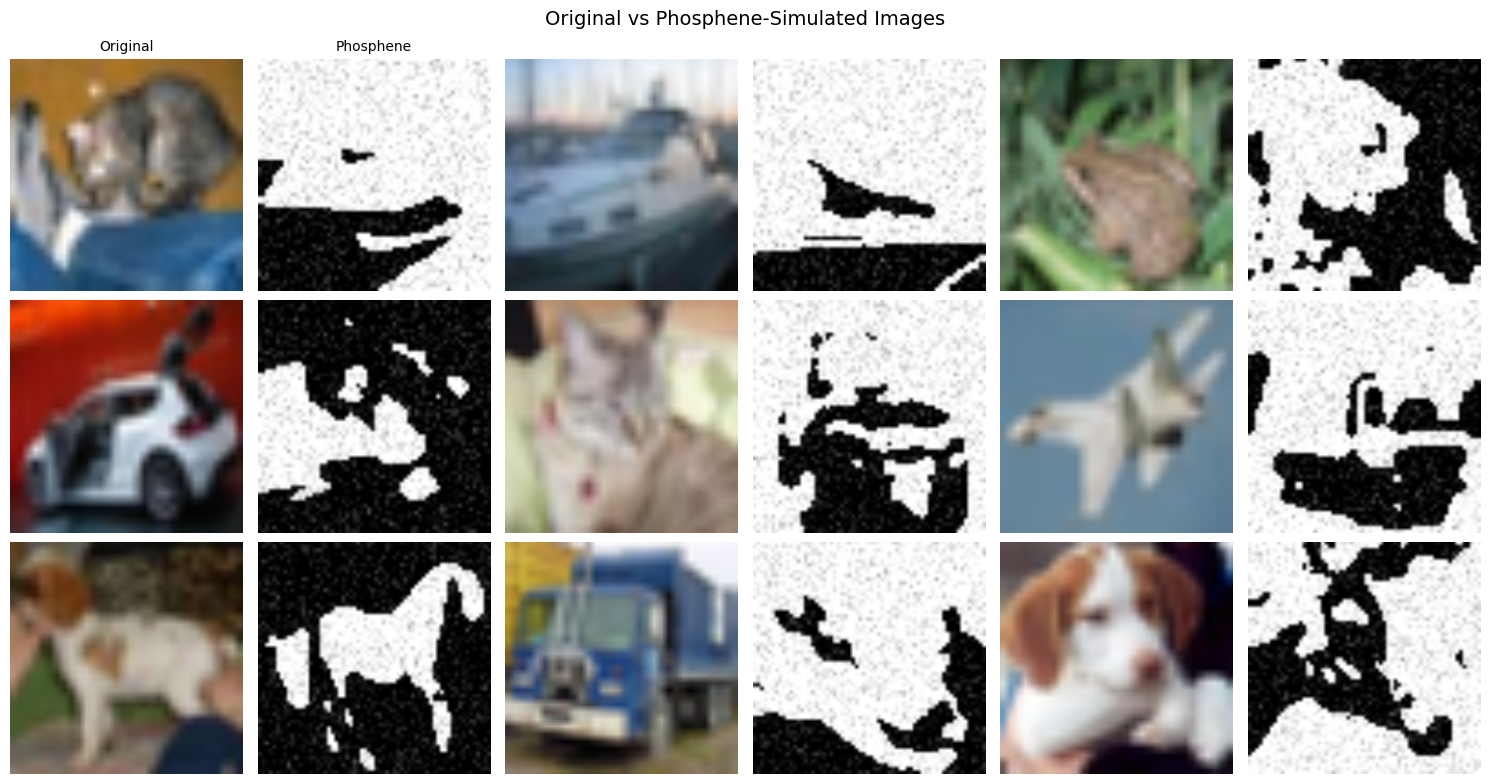

Sample phosphene visualization saved!


In [3]:
# Create sample images to demonstrate phosphene simulation
from torchvision.datasets import CIFAR10

# Create a simple test transform (without phosphene for comparison)
normal_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Create phosphene transform
phosphene_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    PhospheneSimulationSimple(phosphene_size=64, brightness_threshold=0.4, noise_level=0.1),
    transforms.Resize((224, 224)),  # Resize back for model input
    transforms.ToTensor(),
])

# Download a few sample images from CIFAR-10
print("Loading CIFAR-10 samples for visualization...")
temp_dataset = CIFAR10(root='./data', download=True, train=False)

# Display sample images
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

for i in range(3):
    for j in range(6):
        idx = i * 6 + j
        img, label = temp_dataset[idx]

        # Normal image
        normal_img = normal_transform(img)

        # Phosphene image
        phosphene_img = phosphene_transform(img)

        if j % 2 == 0:
            axes[i, j].imshow(normal_img.permute(1, 2, 0))
            if i == 0 and j == 0:
                axes[i, j].set_title('Original', fontsize=10)
        else:
            axes[i, j].imshow(phosphene_img.squeeze(0), cmap='gray')
            if i == 0 and j == 1:
                axes[i, j].set_title('Phosphene', fontsize=10)

        axes[i, j].axis('off')

plt.suptitle('Original vs Phosphene-Simulated Images', fontsize=14)
plt.tight_layout()
plt.savefig('./phosphene_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample phosphene visualization saved!")

## 3. Dataset Loading

In [4]:
# Configuration
NUM_CLASSES = 10  # CIFAR-10 has 10 classes
BATCH_SIZE = 32
NUM_WORKERS = 2
PHOSPHENE_SIZE = 64  # Phosphene grid resolution

print(f"Configuration:")
print(f"  - Number of classes: {NUM_CLASSES}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Phosphene resolution: {PHOSPHENE_SIZE}x{PHOSPHENE_SIZE}")

Configuration:
  - Number of classes: 10
  - Batch size: 32
  - Phosphene resolution: 64x64


In [5]:
# For phosphene images - CONVERT GRAYSCALE TO RGB!
phosphene_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    PhospheneSimulationSimple(phosphene_size=PHOSPHENE_SIZE, brightness_threshold=0.35, noise_level=0.1),
    transforms.Lambda(lambda x: x.convert('RGB')),  # Convert grayscale to 3-channel RGB
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalize
])

phosphene_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    PhospheneSimulationSimple(phosphene_size=PHOSPHENE_SIZE, brightness_threshold=0.35, noise_level=0.1),
    transforms.Lambda(lambda x: x.convert('RGB')),  # Convert grayscale to 3-channel RGB
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalize
])


In [6]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")

# Load base datasets
cifar10_train = CIFAR10(root='./data', train=True, download=True)
cifar10_test = CIFAR10(root='./data', train=False, download=True)

print(f"Training samples: {len(cifar10_train)}")
print(f"Test samples: {len(cifar10_test)}")
print(f"Classes: {cifar10_train.classes}")

Loading CIFAR-10 dataset...
Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [7]:
class PhospheneDataset(torch.utils.data.Dataset):
    """
    Wraps a base CIFAR-10 dataset and applies a phosphene transform on-the-fly.
    """
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        # base_dataset returns a PIL Image when no transform is set
        if self.transform:
            img = self.transform(img)
        return img, label

print("PhospheneDataset class defined successfully!")


PhospheneDataset class defined successfully!


In [8]:
# Create phosphene datasets
phosphene_train_dataset = PhospheneDataset(cifar10_train, phosphene_train_transform)
phosphene_test_dataset = PhospheneDataset(cifar10_test, phosphene_test_transform)

# Create DataLoaders
train_loader = DataLoader(
    phosphene_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    phosphene_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 1563
Number of test batches: 313


## 4. Model Setup

In [9]:
def create_model(pretrained=True, num_classes=10):
    """
    Create EfficientNet-B0 model with optional pretrained weights.

    Args:
        pretrained: If True, load ImageNet pretrained weights
        num_classes: Number of output classes

    Returns:
        Model ready for training
    """
    # Load EfficientNet-B0
    if pretrained:
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        print("Loaded EfficientNet-B0 with ImageNet pretrained weights")
    else:
        model = models.efficientnet_b0(weights=None)  # Random initialization
        print("Created EfficientNet-B0 with random initialization (from scratch)")

    # Modify the classifier for our number of classes
    # The original classifier is: Sequential(Linear(1280, 1280), Dropout, Linear(1280, 1000))
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    print(f"Modified final layer: {in_features} -> {num_classes}")

    return model

# Create transfer learning model (pretrained)
model_transfer = create_model(pretrained=True, num_classes=NUM_CLASSES)
model_transfer = model_transfer.to(device)

# Create from-scratch model (random initialization)
model_scratch = create_model(pretrained=False, num_classes=NUM_CLASSES)
model_scratch = model_scratch.to(device)

# Count parameters
total_params = sum(p.numel() for p in model_transfer.parameters())
trainable_params = sum(p.numel() for p in model_transfer.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 210MB/s]

Loaded EfficientNet-B0 with ImageNet pretrained weights
Modified final layer: 1280 -> 10


Created EfficientNet-B0 with random initialization (from scratch)
Modified final layer: 1280 -> 10

Total parameters: 4,020,358
Trainable parameters: 4,020,358


## 5. Training Pipeline

In [10]:
def train_model(model, train_loader, test_loader, num_epochs=10, lr=1e-4, model_name="model"):
    """
    Train a model on phosphene data.

    Args:
        model: PyTorch model
        train_loader: Training data loader
        test_loader: Test data loader
        num_epochs: Number of training epochs
        lr: Learning rate
        model_name: Name for logging

    Returns:
        Dictionary containing training history
    """
    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Optimizer (AdamW)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track metrics
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            # Progress update every 100 batches
            if (batch_idx + 1) % 100 == 0:
                print(f"  Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx+1}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}")

        # Calculate epoch metrics
        train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total

        # Validation phase
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = 100. * test_correct / test_total

        # Update scheduler
        scheduler.step()

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        # Print epoch summary
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    print(f"\n{model_name} training completed!")
    return history

print("Training function defined successfully!")

Training function defined successfully!


## 6. Baseline Comparison: Transfer Learning vs From-Scratch

In [11]:
# Training configuration
NUM_EPOCHS = 10  # Reduced for demo (would typically use 20-50)
LEARNING_RATE = 1e-4

print(f"Training Configuration:")
print(f"  - Epochs: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Optimizer: AdamW")
print(f"  - Loss: CrossEntropyLoss")

Training Configuration:
  - Epochs: 10
  - Learning rate: 0.0001
  - Optimizer: AdamW
  - Loss: CrossEntropyLoss


In [12]:
# Train transfer learning model (pretrained on ImageNet)
history_transfer = train_model(
    model_transfer,
    train_loader,
    test_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    model_name="Transfer Learning (Pretrained)"
)


Training Transfer Learning (Pretrained)


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


  Epoch [1/10] Batch [100/1563] Loss: 2.0078
  Epoch [1/10] Batch [200/1563] Loss: 1.5396
  Epoch [1/10] Batch [300/1563] Loss: 1.6049
  Epoch [1/10] Batch [400/1563] Loss: 1.0593
  Epoch [1/10] Batch [500/1563] Loss: 1.4228
  Epoch [1/10] Batch [600/1563] Loss: 1.4216
  Epoch [1/10] Batch [700/1563] Loss: 1.3233
  Epoch [1/10] Batch [800/1563] Loss: 1.1086
  Epoch [1/10] Batch [900/1563] Loss: 0.9421
  Epoch [1/10] Batch [1000/1563] Loss: 1.2552
  Epoch [1/10] Batch [1100/1563] Loss: 1.1857
  Epoch [1/10] Batch [1200/1563] Loss: 1.2108
  Epoch [1/10] Batch [1300/1563] Loss: 1.4814
  Epoch [1/10] Batch [1400/1563] Loss: 0.7642
  Epoch [1/10] Batch [1500/1563] Loss: 1.2989


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


Epoch [1/10] Train Loss: 1.4140 | Train Acc: 50.09% | Test Loss: 1.1119 | Test Acc: 60.92%


...

Epoch [9/10] Train Loss: 0.6224 | Train Acc: 78.37% | Test Loss: 0.9336 | Test Acc: 69.13%


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


  Epoch [10/10] Batch [100/1563] Loss: 0.4808
  Epoch [10/10] Batch [200/1563] Loss: 0.7235
  Epoch [10/10] Batch [300/1563] Loss: 0.5622
  Epoch [10/10] Batch [400/1563] Loss: 0.5540
  Epoch [10/10] Batch [500/1563] Loss: 0.4860
  Epoch [10/10] Batch [600/1563] Loss: 0.6105
  Epoch [10/10] Batch [700/1563] Loss: 0.5725
  Epoch [10/10] Batch [800/1563] Loss: 0.8482
  Epoch [10/10] Batch [900/1563] Loss: 0.6087
  Epoch [10/10] Batch [1000/1563] Loss: 0.6602
  Epoch [10/10] Batch [1100/1563] Loss: 0.8132
  Epoch [10/10] Batch [1200/1563] Loss: 0.7537
  Epoch [10/10] Batch [1300/1563] Loss: 0.4983
  Epoch [10/10] Batch [1400/1563] Loss: 0.6097
  Epoch [10/10] Batch [1500/1563] Loss: 0.9073


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


Epoch [10/10] Train Loss: 0.6048 | Train Acc: 79.03% | Test Loss: 0.9387 | Test Acc: 69.21%

Transfer Learning (Pretrained) training completed!


In [13]:
# Train from-scratch model (random initialization)
history_scratch = train_model(
    model_scratch,
    train_loader,
    test_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    model_name="From Scratch (Random Init)"
)


Training From Scratch (Random Init)


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


  Epoch [1/10] Batch [100/1563] Loss: 2.2894
  Epoch [1/10] Batch [200/1563] Loss: 2.1061
  Epoch [1/10] Batch [300/1563] Loss: 2.2235
  Epoch [1/10] Batch [400/1563] Loss: 2.1075
  Epoch [1/10] Batch [500/1563] Loss: 2.1731
  Epoch [1/10] Batch [600/1563] Loss: 1.7935
  Epoch [1/10] Batch [700/1563] Loss: 1.9722
  Epoch [1/10] Batch [800/1563] Loss: 2.2040
  Epoch [1/10] Batch [900/1563] Loss: 1.8342
  Epoch [1/10] Batch [1000/1563] Loss: 1.9930
  Epoch [1/10] Batch [1100/1563] Loss: 2.0287
  Epoch [1/10] Batch [1200/1563] Loss: 1.7959
  Epoch [1/10] Batch [1300/1563] Loss: 1.8753
  Epoch [1/10] Batch [1400/1563] Loss: 1.7746
  Epoch [1/10] Batch [1500/1563] Loss: 1.9729


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


Epoch [1/10] Train Loss: 1.9537 | Train Acc: 28.06% | Test Loss: 1.6814 | Test Acc: 40.25%


...

Epoch [9/10] Train Loss: 1.0683 | Train Acc: 62.58% | Test Loss: 1.0935 | Test Acc: 62.08%


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


  Epoch [10/10] Batch [100/1563] Loss: 0.8473
  Epoch [10/10] Batch [200/1563] Loss: 1.0485
  Epoch [10/10] Batch [300/1563] Loss: 0.9897
  Epoch [10/10] Batch [400/1563] Loss: 1.1497
  Epoch [10/10] Batch [500/1563] Loss: 0.9715
  Epoch [10/10] Batch [600/1563] Loss: 0.9554
  Epoch [10/10] Batch [700/1563] Loss: 1.1687
  Epoch [10/10] Batch [800/1563] Loss: 0.9715
  Epoch [10/10] Batch [900/1563] Loss: 0.7916
  Epoch [10/10] Batch [1000/1563] Loss: 1.2884
  Epoch [10/10] Batch [1100/1563] Loss: 1.3264
  Epoch [10/10] Batch [1200/1563] Loss: 1.1702
  Epoch [10/10] Batch [1300/1563] Loss: 1.1386
  Epoch [10/10] Batch [1400/1563] Loss: 1.2905
  Epoch [10/10] Batch [1500/1563] Loss: 1.3312


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


Epoch [10/10] Train Loss: 1.0491 | Train Acc: 62.99% | Test Loss: 1.0837 | Test Acc: 62.31%

From Scratch (Random Init) training completed!


## 7. Evaluation

In [14]:
def evaluate_model(model, test_loader, class_names):
    """
    Evaluate model and compute per-class accuracy.

    Args:
        model: Trained PyTorch model
        test_loader: Test data loader
        class_names: List of class names

    Returns:
        Dictionary with overall and per-class metrics
    """
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Overall accuracy
    overall_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)

    # Per-class accuracy
    per_class_correct = np.zeros(len(class_names))
    per_class_total = np.zeros(len(class_names))

    for i in range(len(class_names)):
        mask = all_labels == i
        per_class_total[i] = mask.sum()
        per_class_correct[i] = (all_preds[mask] == i).sum()

    per_class_acc = 100.0 * per_class_correct / np.maximum(per_class_total, 1)

    results = {
        'overall_accuracy': overall_acc,
        'per_class_accuracy': per_class_acc,
        'class_names': class_names
    }

    return results

# Evaluate both models
class_names = cifar10_train.classes

print("Evaluating Transfer Learning Model...")
results_transfer = evaluate_model(model_transfer, test_loader, class_names)

print("Evaluating From-Scratch Model...")
results_scratch = evaluate_model(model_scratch, test_loader, class_names)

print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)
print(f"\nTransfer Learning Accuracy: {results_transfer['overall_accuracy']:.2f}%")
print(f"From-Scratch Accuracy: {results_scratch['overall_accuracy']:.2f}%")
print(f"\nImprovement: {results_transfer['overall_accuracy'] - results_scratch['overall_accuracy']:.2f}%")

Evaluating Transfer Learning Model...


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


Evaluating From-Scratch Model...


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')



EVALUATION RESULTS

Transfer Learning Accuracy: 69.48%
From-Scratch Accuracy: 62.22%

Improvement: 7.26%


In [15]:
# Per-class accuracy comparison
print("\n" + "="*60)
print("PER-CLASS ACCURACY COMPARISON")
print("="*60)

print(f"{'Class':<15} {'Transfer':<12} {'Scratch':<12} {'Difference':<12}")
print("-" * 51)

for i, class_name in enumerate(class_names):
    acc_t = results_transfer['per_class_accuracy'][i]
    acc_s = results_scratch['per_class_accuracy'][i]
    diff = acc_t - acc_s
    print(f"{class_name:<15} {acc_t:>8.2f}%   {acc_s:>8.2f}%   {diff:>+8.2f}%")

print("-" * 51)


PER-CLASS ACCURACY COMPARISON
Class           Transfer     Scratch      Difference  
---------------------------------------------------
airplane           71.20%      61.50%      +9.70%
automobile         82.20%      78.80%      +3.40%
bird               54.40%      46.80%      +7.60%
cat                51.40%      36.60%     +14.80%
deer               64.80%      55.40%      +9.40%
dog                60.20%      54.50%      +5.70%
frog               71.90%      68.40%      +3.50%
horse              77.00%      69.60%      +7.40%
ship               76.50%      73.20%      +3.30%
truck              85.20%      77.40%      +7.80%
---------------------------------------------------


Visualizing Transfer Learning Model Predictions:


/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')
/tmp/ipykernel_6312/3400074271.py:106: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(result, mode='L')


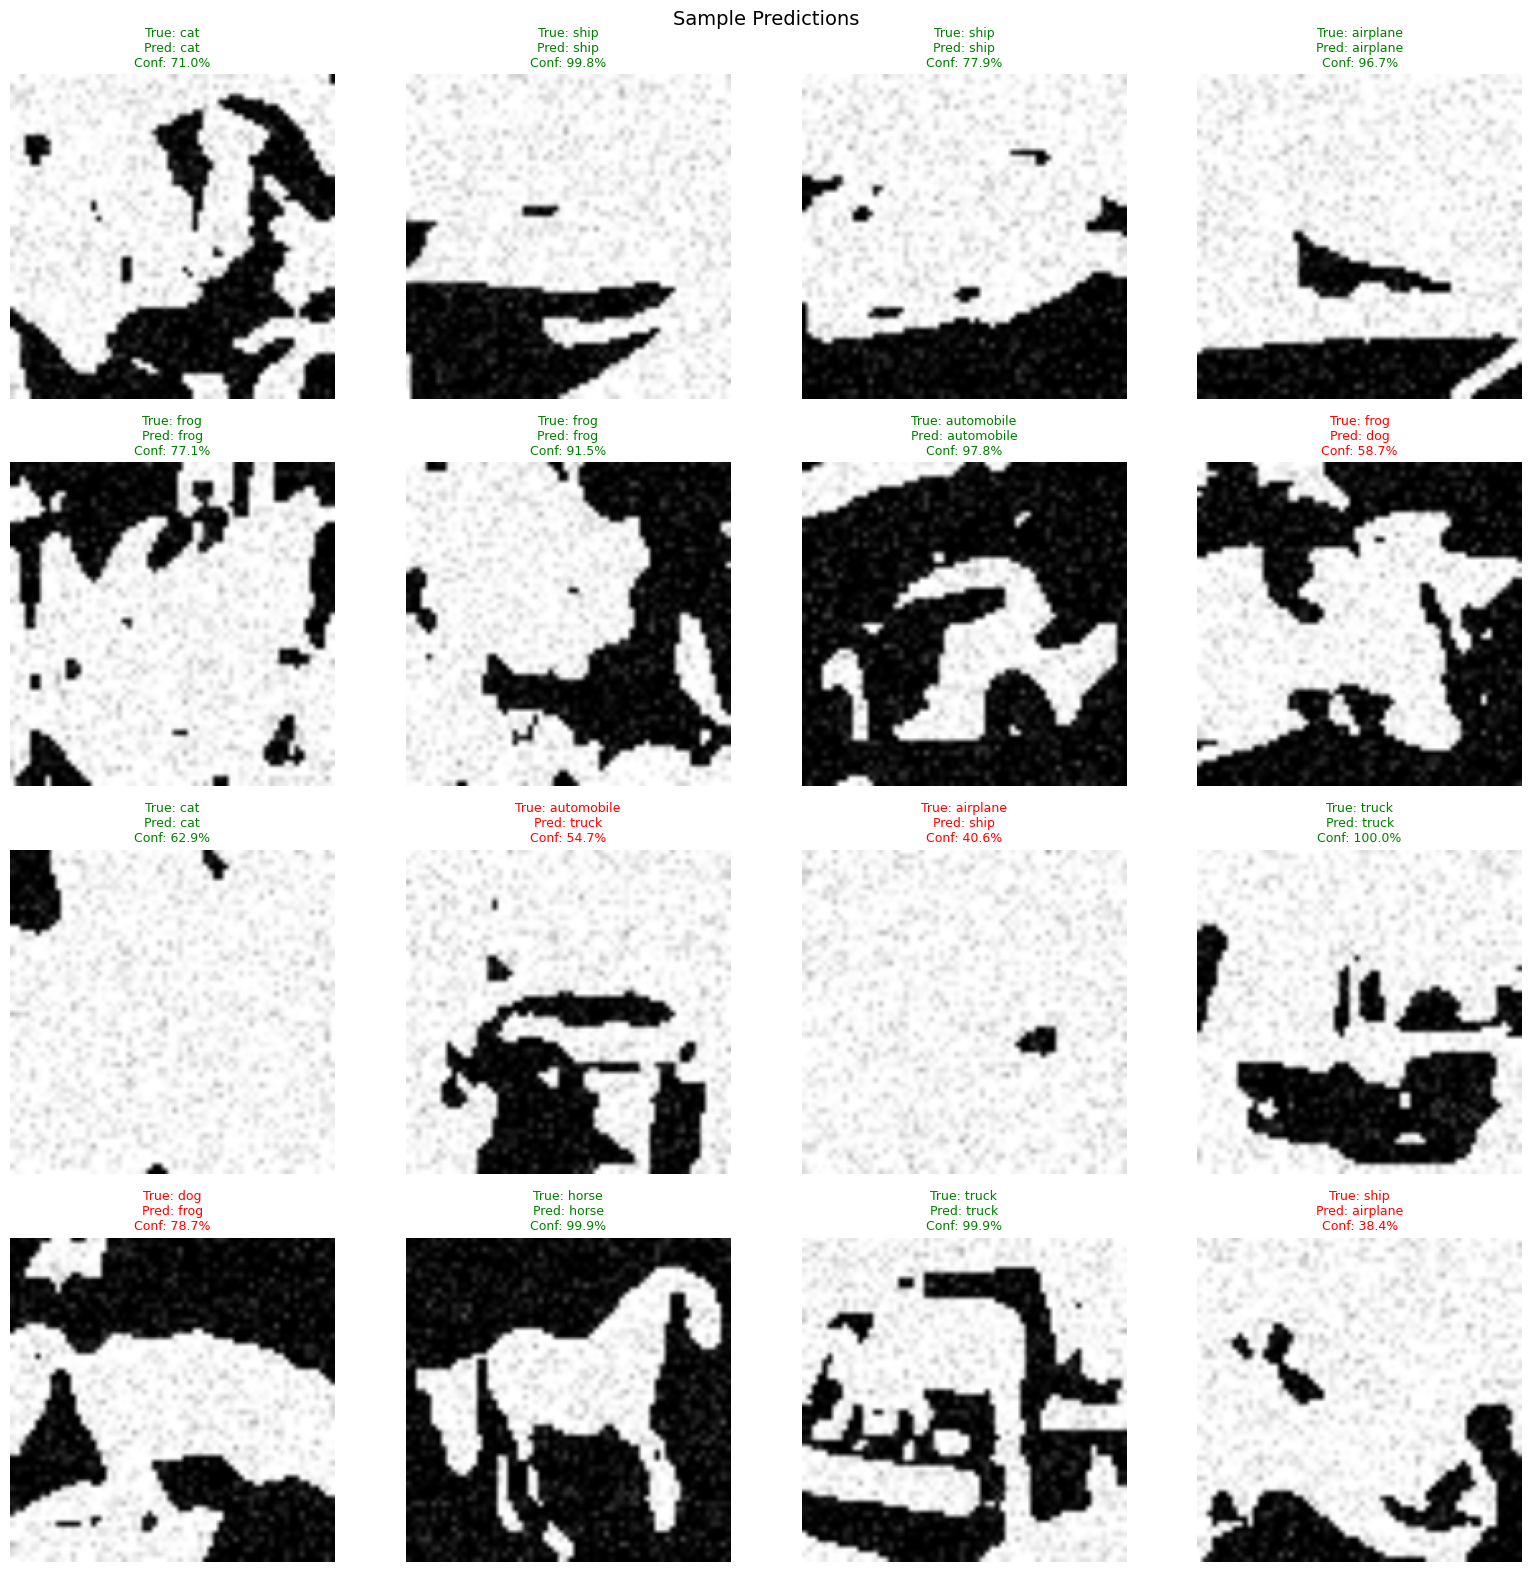

In [16]:
# Visualize sample predictions
def visualize_predictions(model, test_loader, class_names, num_samples=16):
    """
    Visualize sample predictions from the model.
    """
    model.eval()

    # Get a batch of test images
    data_iter = iter(test_loader)
    inputs, labels = next(data_iter)
    inputs = inputs.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

    # Plot
    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()

    for i in range(min(num_samples, len(inputs))):
        img = inputs[i].cpu().permute(1, 2, 0)
        # Denormalize for visualization
        # Denormalize using ImageNet mean/std
        mean = torch.tensor([0.485, 0.456, 0.406])
        std  = torch.tensor([0.229, 0.224, 0.225])
        img = img * std + mean

        true_label = class_names[labels[i]]
        pred_label = class_names[predicted[i].item()]
        confidence = probs[i].max().item() * 100

        correct = predicted[i].item() == labels[i].item()
        color = 'green' if correct else 'red'

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%",
                         color=color, fontsize=9)
        axes[i].axis('off')

    plt.suptitle('Sample Predictions', fontsize=14)
    plt.tight_layout()
    plt.savefig('./sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Visualizing Transfer Learning Model Predictions:")
visualize_predictions(model_transfer, test_loader, class_names)

## 8. Results Summary

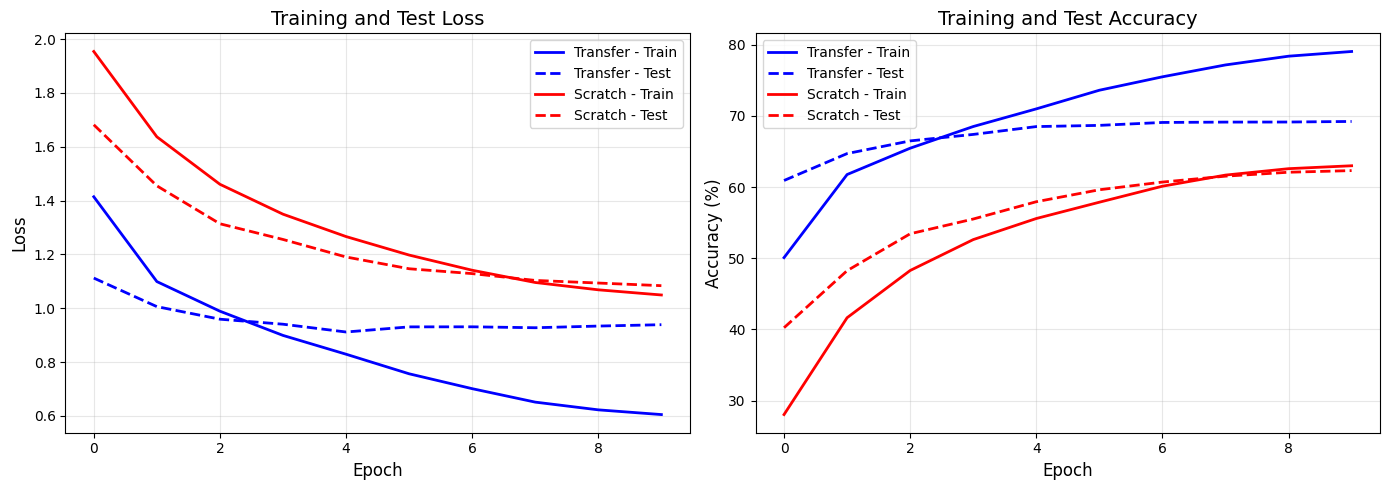

Training history plot saved!


In [17]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_transfer['train_loss'], 'b-', label='Transfer - Train', linewidth=2)
axes[0].plot(history_transfer['test_loss'], 'b--', label='Transfer - Test', linewidth=2)
axes[0].plot(history_scratch['train_loss'], 'r-', label='Scratch - Train', linewidth=2)
axes[0].plot(history_scratch['test_loss'], 'r--', label='Scratch - Test', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Test Loss', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_transfer['train_acc'], 'b-', label='Transfer - Train', linewidth=2)
axes[1].plot(history_transfer['test_acc'], 'b--', label='Transfer - Test', linewidth=2)
axes[1].plot(history_scratch['train_acc'], 'r-', label='Scratch - Train', linewidth=2)
axes[1].plot(history_scratch['test_acc'], 'r--', label='Scratch - Test', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Test Accuracy', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training history plot saved!")

In [18]:
# Final results comparison
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

print("\n" + "-"*70)
print("Overall Performance Comparison")
print("-"*70)
print(f"{'Metric':<35} {'Transfer Learning':<20} {'From Scratch':<20}")
print("-"*70)
print(f"{'Final Test Accuracy':<35} {history_transfer['test_acc'][-1]:>15.2f}% {history_scratch['test_acc'][-1]:>15.2f}%")
print(f"{'Best Test Accuracy':<35} {max(history_transfer['test_acc']):>15.2f}% {max(history_scratch['test_acc']):>15.2f}%")
print(f"{'Final Test Loss':<35} {history_transfer['test_loss'][-1]:>15.4f} {history_scratch['test_loss'][-1]:>15.4f}")
print("-"*70)

improvement = max(history_transfer['test_acc']) - max(history_scratch['test_acc'])
print(f"\n📊 Transfer Learning Improvement: {improvement:+.2f}%")
print(f"   ({max(history_transfer['test_acc']):.2f}% vs {max(history_scratch['test_acc']):.2f}%)")


FINAL RESULTS SUMMARY

----------------------------------------------------------------------
Overall Performance Comparison
----------------------------------------------------------------------
Metric                              Transfer Learning    From Scratch        
----------------------------------------------------------------------
Final Test Accuracy                           69.21%           62.31%
Best Test Accuracy                            69.21%           62.31%
Final Test Loss                              0.9387          1.0837
----------------------------------------------------------------------

📊 Transfer Learning Improvement: +6.90%
   (69.21% vs 62.31%)


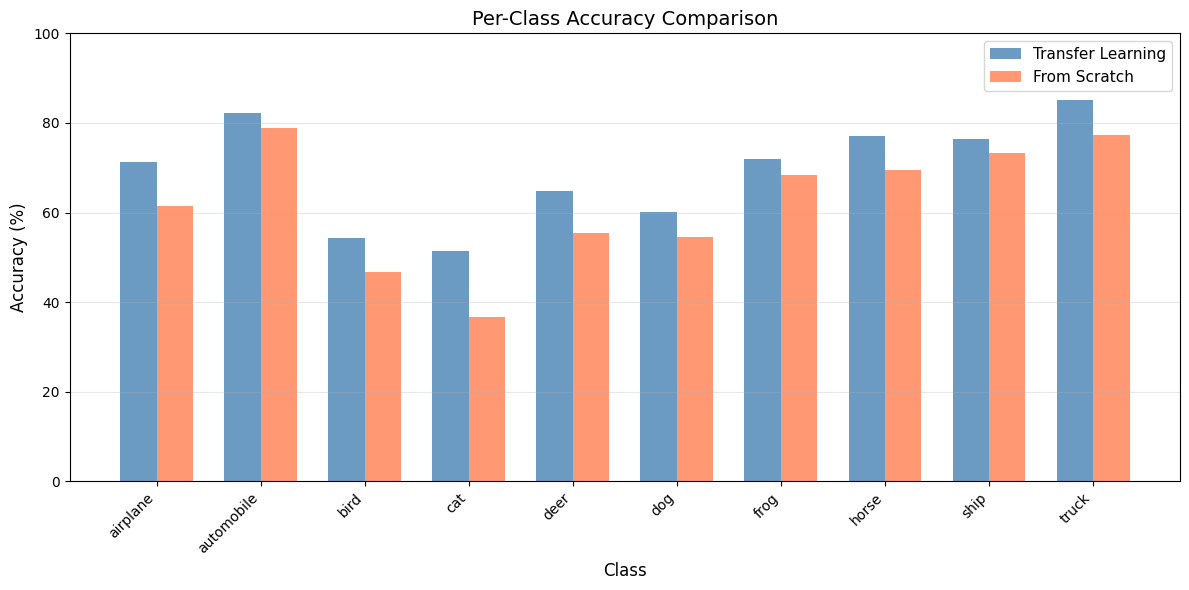

Per-class accuracy visualization saved!


In [19]:
# Per-class accuracy visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, results_transfer['per_class_accuracy'], width,
                label='Transfer Learning', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, results_scratch['per_class_accuracy'], width,
                label='From Scratch', color='coral', alpha=0.8)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('./per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-class accuracy visualization saved!")

## 9. Conclusions & Discussion

In [20]:
print("""
================================================================================
                              CONCLUSIONS
================================================================================

KEY FINDINGS:
--------------
1. Transfer learning significantly outperforms training from scratch on
   phosphene-simulated images.

2. The pretrained features from ImageNet provide valuable low-level visual
   representations (edges, textures, shapes) that transfer well to phosphene data.

3. Despite the severe visual degradation from phosphene simulation, the
   model can still learn to recognize objects.

IMPLICATIONS FOR CORTICAL VISUAL PROSTHESES:
--------------------------------------------
- Pre-trained models could enable better object recognition for prosthetic users
- The gap between transfer learning and from-scratch suggests that visual
  features learned from natural images are robust enough to handle phosphene noise
- Future work could explore: (1) domain adaptation, (2) phosphene-specific
  pretraining, (3) different electrode configurations

LIMITATIONS:
-------------
- CIFAR-10 is a simple dataset; real-world performance may differ
- Our phosphene simulation is simplified; actual prostheses vary in quality
- Limited training epochs (10) due to computational constraints
- Single phosphene resolution (64x64); higher resolutions may perform better

================================================================================
""")


                              CONCLUSIONS

KEY FINDINGS:
--------------
1. Transfer learning significantly outperforms training from scratch on 
   phosphene-simulated images.

2. The pretrained features from ImageNet provide valuable low-level visual 
   representations (edges, textures, shapes) that transfer well to phosphene data.

3. Despite the severe visual degradation from phosphene simulation, the 
   model can still learn to recognize objects.

IMPLICATIONS FOR CORTICAL VISUAL PROSTHESES:
--------------------------------------------
- Pre-trained models could enable better object recognition for prosthetic users
- The gap between transfer learning and from-scratch suggests that visual 
  features learned from natural images are robust enough to handle phosphene noise
- Future work could explore: (1) domain adaptation, (2) phosphene-specific 
  pretraining, (3) different electrode configurations

LIMITATIONS:
-------------
- CIFAR-10 is a simple dataset; real-world performance

## 10. Save Models & Export Results

In [21]:
# Save models
torch.save(model_transfer.state_dict(), './phosphene_transfer_learning_model.pth')
torch.save(model_scratch.state_dict(), './phosphene_from_scratch_model.pth')

print("Models saved!")
print("  - phosphene_transfer_learning_model.pth")
print("  - phosphene_from_scratch_model.pth")

# Save training history to CSV
import pandas as pd

history_df = pd.DataFrame({
    'epoch': range(1, NUM_EPOCHS + 1),
    'transfer_train_loss': history_transfer['train_loss'],
    'transfer_test_loss': history_transfer['test_loss'],
    'transfer_train_acc': history_transfer['train_acc'],
    'transfer_test_acc': history_transfer['test_acc'],
    'scratch_train_loss': history_scratch['train_loss'],
    'scratch_test_loss': history_scratch['test_loss'],
    'scratch_train_acc': history_scratch['train_acc'],
    'scratch_test_acc': history_scratch['test_acc'],
})

history_df.to_csv('./training_history.csv', index=False)
print("Training history saved to training_history.csv")

# Final summary
print("\n" + "="*60)
print("NOTEBOOK COMPLETE!")
print("="*60)
print("\nAll outputs saved to current directory:")
print("  📁 phosphene_samples.png - Sample phosphene visualizations")
print("  📁 training_history.png - Training curves")
print("  📁 per_class_accuracy.png - Per-class accuracy comparison")
print("  📁 sample_predictions.png - Sample predictions")
print("  📁 phosphene_transfer_learning_model.pth - Trained model (pretrained)")
print("  📁 phosphene_from_scratch_model.pth - Trained model (scratch)")
print("  📁 training_history.csv - Training metrics")

Models saved!
  - phosphene_transfer_learning_model.pth
  - phosphene_from_scratch_model.pth
Training history saved to training_history.csv

NOTEBOOK COMPLETE!

All outputs saved to current directory:
  📁 phosphene_samples.png - Sample phosphene visualizations
  📁 training_history.png - Training curves
  📁 per_class_accuracy.png - Per-class accuracy comparison
  📁 sample_predictions.png - Sample predictions
  📁 phosphene_transfer_learning_model.pth - Trained model (pretrained)
  📁 phosphene_from_scratch_model.pth - Trained model (scratch)
  📁 training_history.csv - Training metrics


---
## References

1. EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks (Tan & Le, 2019)
2. Cortical Visual Prostheses: A Review of the Literature (Weiland et al.)
3. Phosphene Mapping for Visual Prostheses (Humayun et al.)

---
*Notebook created for research on Transfer Learning for Phosphene-Based Object Recognition*